---------
# Modelo BERTimbau BASE 
-----------

In [1]:
# ==============================================================================
# 1. IMPORTAÇÕES
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import os
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from datasets import Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    pipeline,
    TrainingArguments,
    DataCollatorWithPadding
)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

d:\Programs\Python 3.12.0\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# Mostra o texto completo em cada célula
# ==========================================
pd.set_option("display.max_colwidth", None)  

In [3]:
# ==========================================
# Carregar o dataset
# ==========================================
df = pd.read_pickle('Reviews_Lisboa_RJ_200k_texto_limpo.pkl')
df.head()

,id,date,comments,cidade,lang,texto_limpo
0,1450109880518848792,2025-06-23,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",Rio de Janeiro,pt,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada"
1,617993232260012422,2022-05-02,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje .<br/>Vou falar 4 coisas que não poderia deixar passar.<br/>01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional.<br/>02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça.<br/>03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas.<br/>04- A localização do apartamento é fantástica pois fica pórximo a tudo.<br/>Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico !!!",Rio de Janeiro,pt,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje . Vou falar 4 coisas que não poderia deixar passar. 01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional. 02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça. 03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas. 04- A localização do apartamento é fantástica pois fica pórximo a tudo. Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico ! ! !"
2,1490668744495176611,2025-08-18,"o apt do Maurício é otimo!!! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca",Rio de Janeiro,pt,"o apt do Maurício é otimo! ! ! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca"
3,1147883300514198966,2024-05-02,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo.",Rio de Janeiro,pt,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo."
4,1247881696472392123,2024-09-17,"Incrível! Amei tudo. Super rápida em soluções e respostas. Localização melhor, impossível!",Rio de Janeiro,pt,"Incrível! Amei tudo. Super rápida em soluções e respostas. Localização melhor, impossível!"


-----------
# Fazer a analise de sentimento aplicando rotulos
-----------

In [ ]:
# ==========================================
# Definir modelo base
# ==========================================
model_base = "neuralmind/bert-base-portuguese-cased"

# ==========================================
# Carregar tokenizer e modelo
# ==========================================
tokenizer = AutoTokenizer.from_pretrained(model_base, do_lower_case=False)

model = AutoModelForSequenceClassification.from_pretrained(
    model_base,
    num_labels=3,  # Rótulos: negativo, neutro, positivo
    id2label={0: "NEGATIVO", 1: "NEUTRO", 2: "POSITIVO"},
    label2id={"NEGATIVO": 0, "NEUTRO": 1, "POSITIVO": 2}
)

# ==========================================
# Criar pipeline de classificação
# ==========================================
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=-1
)

# ==========================================
# Função para processar em lotes
# ==========================================
def analisar_sentimento_lote(textos, lote_size=16):
    resultados = []
    for i in range(0, len(textos), lote_size):
        lote = textos[i:i + lote_size]
        resultado_lote = classifier(
            lote,
            truncation=True,
            max_length=512
        )
        resultados.extend(resultado_lote)
    return resultados

# ==========================================
# Aplicar ao DataFrame
# ==========================================
df["texto_limpo"] = df["texto_limpo"].astype(str)

df["Base-analise_sentimento"] = analisar_sentimento_lote(
    df["texto_limpo"].tolist(),
    lote_size=16
)

# ==========================================
# Extrair label e score
# ==========================================
df["Base-sentimento"] = df["Base-analise_sentimento"].apply(lambda x: x["label"])
df["Base-confianca"] = df["Base-analise_sentimento"].apply(lambda x: x["score"])

# ==========================================
# Ver resultados
# ==========================================
display(df[["texto_limpo", "Base-analise_sentimento", "Base-sentimento", "Base-confianca"]].head(10))
print("\nDistribuição de sentimentos:")
print(df["Base-sentimento"].value_counts())

# ==========================================
# Salvar dataset
# ==========================================
df.to_pickle("Reviews_BERTimbau_base.pkl")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12089.96it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# ==========================================
# Verificar dataset rotulado
# ==========================================
df.head()

,date,comments,cidade,lang,texto_limpo,Base-analise_sentimento,Base-sentimento,Base-confianca
0,2025-06-23,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",Rio de Janeiro,pt,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada","{'label': 'POSITIVO', 'score': 0.4085640013217926}",POSITIVO,0.408564
1,2022-05-02,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje .<br/>Vou falar 4 coisas que não poderia deixar passar.<br/>01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional.<br/>02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça.<br/>03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas.<br/>04- A localização do apartamento é fantástica pois fica pórximo a tudo.<br/>Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico !!!",Rio de Janeiro,pt,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje . Vou falar coisas que não poderia deixar passar. - A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional. - A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça. - A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas. - A localização do apartamento é fantástica pois fica pórximo a tudo. Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico ! ! !","{'label': 'NEGATIVO', 'score': 0.4087783396244049}",NEGATIVO,0.408778
2,2025-08-18,"o apt do Maurício é otimo!!! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca",Rio de Janeiro,pt,"o apt do Maurício é otimo! ! ! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca","{'label': 'NEGATIVO', 'score': 0.4266848862171173}",NEGATIVO,0.426685
3,2024-05-02,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo.",Rio de Janeiro,pt,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo.","{'label': 'NEGATIVO', 'score': 0.40583062171936035}",NEGATIVO,0.405831
4,2024-09-17,"Incrível! Amei tudo. Super rápida em soluções e respostas. Localização melhor, impossível!",Rio de Janeiro,pt,"Incrível! Amei tudo. Super rápida em soluções e respostas. Localização melhor, impossível!","{'label': 'POSITIVO', 'score': 0.4076005816459656}",POSITIVO,0.407601


In [ ]:
# ==========================================
# Salvar dataset com as colunas rotuladas
# ==========================================
df.to_pickle("Reviews_BERTimbau_base.pkl")

-------
# Percentagem dos rótulos da Análise de sentimento
----------

In [ ]:
# ==========================================
# Carregar dataset rotulado
# ==========================================
df_base = pd.read_pickle("Reviews_BERTimbau_base.pkl")

In [ ]:
# ==========================================
# Criar tabela a partir da coluna 'sentimento'
# ==========================================
contagens = df_base['Base-sentimento'].value_counts()
percentagens = df_base['Base-sentimento'].value_counts(normalize=True).mul(100).round(1)

sentimentos = pd.DataFrame({
    'Base-sentimento': contagens.index,
    'contagem': contagens.values,
    'percentagem': percentagens.values
})

# ==========================================
# Criar coluna formatada para apresentação
# ==========================================
sentimentos['percentagem_label'] = sentimentos['percentagem'].astype(str) + '%'

# ==========================================
# Mostrar tabela em formato DataFrame
# ==========================================
print("Analise de Sentimento Dataset Total")
display(sentimentos[['Base-sentimento', 'contagem', 'percentagem_label']])

Analise de Sentimento Dataset Total


,Base-sentimento,contagem,percentagem_label
0,POSITIVO,101593,50.8%
1,NEGATIVO,96388,48.2%
2,NEUTRO,2019,1.0%


---------
# Gráfico para análise dos rótulos de sentimento
---------

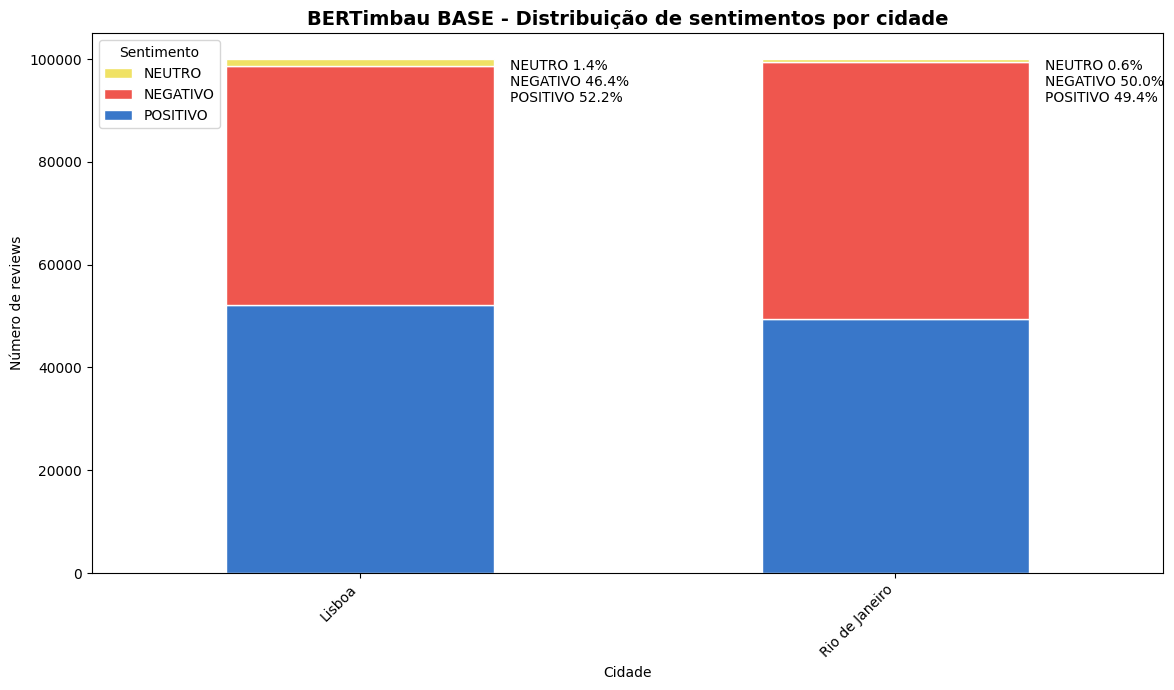

In [14]:
# ==========================================
# Agrupar por cidade e sentimento
# ==========================================
dados_cidade = df_base.groupby(['cidade', 'Base-sentimento']).size().unstack(fill_value=0)

# ==========================================
# Garantir ordem das colunas
# ==========================================
ordem_sentimento = ['POSITIVO', 'NEGATIVO', 'NEUTRO']
dados_cidade = dados_cidade.reindex(columns=[c for c in ordem_sentimento if c in dados_cidade.columns], fill_value=0)

# ==========================================
# Cores
# ==========================================
cores = {
    'POSITIVO': '#3977C9',
    'NEGATIVO': '#EF564E',
    'NEUTRO': '#F0E265'
}

# ==========================================
# Percentagens por cidade
# ==========================================
dados_percent = dados_cidade.div(dados_cidade.sum(axis=1), axis=0) * 100

# ==========================================
# Totais por cidade
# ==========================================
totais = dados_cidade.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 7))

dados_cidade.plot(
    kind='bar',
    stacked=True,
    color=[cores[col] for col in dados_cidade.columns],
    edgecolor='white',
    ax=ax
)

# ==========================================
# Percentagens ao lado de cada barra, em ordem invertida
# ==========================================
for i, cidade in enumerate(dados_cidade.index):
    texto = (
        f"NEUTRO {dados_percent.loc[cidade, 'NEUTRO']:.1f}%\n"
        f"NEGATIVO {dados_percent.loc[cidade, 'NEGATIVO']:.1f}%\n"
        f"POSITIVO {dados_percent.loc[cidade, 'POSITIVO']:.1f}%"
    )
    ax.text(
        i + 0.28,
        totais.loc[cidade],
        texto,
        ha='left',
        va='top',
        fontsize=10
    )

# ==========================================
# Legenda
# ==========================================
handles = [
    Patch(facecolor=cores['NEUTRO'], edgecolor='white', label='NEUTRO'),
    Patch(facecolor=cores['NEGATIVO'], edgecolor='white', label='NEGATIVO'),
    Patch(facecolor=cores['POSITIVO'], edgecolor='white', label='POSITIVO')
]
ax.legend(handles=handles, title='Sentimento')

ax.set_title('BERTimbau BASE - Distribuição de sentimentos por cidade', fontsize=14, loc='center', fontweight='bold')
ax.set_xlabel('Cidade')
ax.set_ylabel('Número de reviews')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('distribuicao_sentimentos_por_cidade.png', dpi=300)
plt.show()